In [1]:
%%capture
# Use Gpu
!pip install dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html

In [2]:
%%capture
!pip install networkx
!pip install slither-analyzer

In [3]:
from dgl.nn.pytorch.explain import GNNExplainer
import json

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import os
from dgl.dataloading import GraphDataLoader
from concurrent.futures import ThreadPoolExecutor
from torch import Tensor
import dgl
import random
import numpy as np
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
from dgl.nn.pytorch.explain import PGExplainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
from dgl.nn import GraphConv, GATConv, TAGConv, SAGEConv, GINConv, AvgPooling, MaxPooling, SumPooling, SortPooling, GlobalAttentionPooling, SetTransformerEncoder, SetTransformerDecoder

def seed_everything(seed: int):
    # Hàm đặt seed cố định cho tất cả các thư viện để kết quả có thể tái tạo lại được
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)  # Cố định seed cho thư viện random
    # os.environ['PYTHONHASHSEED'] = str(seed)  # Cố định hash seed của Python
    np.random.seed(seed)  # Cố định seed cho NumPy
    torch.manual_seed(seed)  # Cố định seed cho PyTorch CPU
    torch.cuda.manual_seed(seed)  # Cố định seed cho PyTorch GPU
    torch.backends.cudnn.deterministic = True  # Đảm bảo tính nhất quán của thuật toán cuDNN
    torch.backends.cudnn.benchmark = True  # Tối ưu hóa tốc độ tính toán

# Dataset loading functions
def readData(path: str, n_nscam: int, n_scam: int):
    dic = {
        "filename": [],
        "label": []
    }
    cnt0, cnt1 = 0, 0
    for label in ["NonVulnerable_Fcg", "Vulnerable_Fcg"]:
        for file in sorted(os.listdir(os.path.join(path, label))):
            if file.endswith(".fcg"):
                if label == "NonVulnerable_Fcg":
                    if cnt0 < n_nscam:
                        dic['filename'].append(os.path.join(path, label, file))
                        dic['label'].append(0)
                        cnt0 += 1
                else:
                    if cnt1 < n_scam:
                        dic['filename'].append(os.path.join(path, label, file))
                        dic['label'].append(1)
                        cnt1 += 1
    df = pd.DataFrame(dic)
    return df

def loadfeatureGraph_100(path):
    g = dgl.load_graphs(path)[0][0]

# -------------------------------------------
    label = None
    if "NonVulnerable_Fcg" in path:
        label = 0
    else:
        label = 1        
    file_path_split = path.split("/")
    info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
    info_data = json.load(open(info_path, "r"))

    new_node_label = []
    for name, code in info_data['code'].items():
        if "Reentrancy" in info_path:
            if "call.value" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)
        else:
            if "block.timestamp" in code or "now" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)

    g.ndata['node_label'] = torch.tensor(new_node_label)
# -------------------------------------------
    
    g.ndata["features"] = g.ndata["featuresH"]
    return g, label

def createBatchMulThread_MultiOp(data, max_works, nfeatures):
    pathfiles = data
    if nfeatures == 768:
        with ThreadPoolExecutor(max_works) as executor:
            graph_n_label = list(executor.map(loadfeatureGraph_100, pathfiles))
    graphs, labels = [], []
    for g, label in graph_n_label:
        cnt = 0
        for nlabel in g.ndata['node_label'].tolist():
            if nlabel == 1:
                cnt += 1
        num_classes = len(torch.unique(g.ndata['node_label']))
        if cnt == 1:
            graphs.append(g)
            labels.append(label)
    # graphs, labels = [], []
    # for graph, label in graph_n_label:
    #     graphs.append(graph)
    #     labels.append(label)
            
    return graphs, labels

class GraphDataset(dgl.data.DGLDataset):
    def __init__(self, graphs, labels):
        super().__init__(name='graph_dataset')
        self.graphs = graphs
        self.labels = labels
    
    def process(self):
        pass
    
    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]
    
    def __len__(self):
        return len(self.graphs)

# MultiHeadCrossAttentionPooling
class MultiHeadCrossAttentionPooling(nn.Module):
    def __init__(self, hidden_dim, num_query_vectors=1, num_heads=4):
        super(MultiHeadCrossAttentionPooling, self).__init__()
        self.num_query_vectors = num_query_vectors
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        
        self.query = nn.Parameter(torch.randn(num_query_vectors, hidden_dim))
        self.key_transform = nn.Linear(hidden_dim, hidden_dim)
        self.value_transform = nn.Linear(hidden_dim, hidden_dim)
        self.output_projection = nn.Linear(hidden_dim, hidden_dim)
        self.output_dim = hidden_dim * num_query_vectors
        
    def forward(self, g, h):
        graph_splits = g.batch_num_nodes()
        batch_size = len(graph_splits)
        device = h.device
        output = torch.zeros(batch_size, self.output_dim, device=device)
        
        keys = self.key_transform(h)
        values = self.value_transform(h)
        keys = keys.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        values = values.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        query = self.query.view(self.num_query_vectors, self.num_heads, -1)
        
        start_idx = 0
        for i, num_nodes in enumerate(graph_splits):
            end_idx = start_idx + num_nodes
            graph_keys = keys[start_idx:end_idx]
            graph_values = values[start_idx:end_idx]
            scores = torch.matmul(query.permute(1, 0, 2), graph_keys.permute(1, 2, 0))
            attention_weights = F.softmax(scores / (self.hidden_dim // self.num_heads) ** 0.5, dim=-1)
            head_outputs = torch.matmul(attention_weights, graph_values.permute(1, 0, 2))
            multi_head_output = head_outputs.permute(1, 0, 2).reshape(self.num_query_vectors, -1)
            projected_output = self.output_projection(multi_head_output)
            output[i] = projected_output.reshape(-1)
            start_idx = end_idx
        return output

# Convolution and Pooling Helpers
def get_convolution_layer(input_dimension: int, output_dimension: int, name: list, agg_hidden_dimension: int = 1024, heads: int = 0):
    mlp, gin_agg, sage_agg = None, 'sum', 'mean'
    if name[0] == "GIN":
        mlp = nn.Sequential(
            nn.Linear(input_dimension, agg_hidden_dimension),
            nn.ReLU(),
            nn.Linear(agg_hidden_dimension, output_dimension)
        )
        gin_agg = name[1]
    if name[0] == "SAGE":
        sage_agg = name[1]
    return {
        "GCN": GraphConv(input_dimension, output_dimension, activation=F.relu, allow_zero_in_degree=True),
        "SAGE": SAGEConv(input_dimension, output_dimension, activation=F.relu, norm=F.normalize, aggregator_type=sage_agg),
        "GAT": GATConv(input_dimension, output_dimension, num_heads=heads, activation=F.relu, feat_drop=0.0, attn_drop=0.0),
        "TAG": TAGConv(input_dimension, output_dimension, k=4, activation=F.relu),
        "GIN": GINConv(apply_func=mlp, activation=F.relu, aggregator_type=gin_agg)
    }.get(name[0], None)

def get_pooling_method(method_name: str, hidden_dim: int = None):
    return {
        "max": MaxPooling(),
        "mean": AvgPooling(),
        "sum": SumPooling(),
        "sort": SortPooling(k=3),
        "transformer": (SetTransformerEncoder(5, 4, 4, 20), SetTransformerDecoder(5, 4, 4, 20, 1, 3)),
        "global_attention": GlobalAttentionPooling(gate_nn=nn.Linear(hidden_dim, 1), feat_nn=nn.Linear(hidden_dim, hidden_dim)),
        "cross_attention": MultiHeadCrossAttentionPooling(hidden_dim=hidden_dim, num_query_vectors=4)
    }.get(method_name, None)

# GraphNN Model
class GraphNN(nn.Module):
    def __init__(self, mtype, feat, hfeats: list, fc1_layer, fc2_layer, outclass, gptype='max', ginfeat=None, num_query_vectors=1):
        super(GraphNN, self).__init__()
        self.mtype = mtype
        self.gptype = gptype
        self.hfeats = hfeats
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        if mtype[0] == "GIN":
            self.conv1 = get_convolution_layer(input_dimension=feat, output_dimension=hfeats[0], name=mtype, agg_hidden_dimension=ginfeat)
            if len(hfeats) >= 2:
                self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1], name=mtype, agg_hidden_dimension=ginfeat)
            if len(hfeats) >= 3:
                self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2], name=mtype, agg_hidden_dimension=ginfeat)
        else:
            if mtype != ["GAT"]:
                self.conv1 = get_convolution_layer(input_dimension=feat, output_dimension=hfeats[0], name=mtype)
                if len(hfeats) >= 2:
                    self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1], name=mtype)
                if len(hfeats) >= 3:
                    self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2], name=mtype)
            else:
                if len(hfeats) > 1:
                    self.conv1 = get_convolution_layer(input_dimension=feat, output_dimension=hfeats[0], name=mtype, heads=8)
                elif len(hfeats) == 1:
                    self.conv1 = get_convolution_layer(input_dimension=feat, output_dimension=hfeats[0], name=mtype, heads=1)
                if len(hfeats) > 2:
                    self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=(hfeats[1] * 8), name=mtype, heads=8)
                elif len(hfeats) == 2:
                    self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=hfeats[1], name=mtype, heads=1)
                if len(hfeats) == 3:
                    self.conv3 = get_convolution_layer(input_dimension=(hfeats[1] * 8), output_dimension=hfeats[2], name=mtype, heads=1)

        if gptype == 'cross_attention':
            self.pooling = MultiHeadCrossAttentionPooling(hidden_dim=hfeats[-1], num_query_vectors=num_query_vectors)
            fc1_input_dim = hfeats[-1] * num_query_vectors
        else:
            self.pooling = get_pooling_method(gptype, hidden_dim=hfeats[-1])
            fc1_input_dim = hfeats[-1]

        self.fc1 = nn.Linear(fc1_input_dim, fc1_layer)
        self.fc2 = nn.Linear(fc1_layer, fc2_layer)
        self.fc3 = nn.Linear(fc2_layer, outclass)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, graph, feat, embed=False, graph_embed=False, node_vec=False, eweight=None):
        if node_vec:
            return feat
        if self.mtype[0] == "GCN":
            h = self.conv1(graph, feat, edge_weight=eweight)
            if len(self.hfeats) >= 2:
                h = self.conv2(graph, h, edge_weight=eweight)
            if len(self.hfeats) >= 3:
                h = self.conv3(graph, h, edge_weight=eweight)
        else:
            h = self.conv1(graph, feat)
            if self.mtype == ["GAT"]:
                h = h.reshape(h.shape[0], -1)
            if len(self.hfeats) >= 2:
                h = self.conv2(graph, h)
                if self.mtype == ["GAT"]:
                    h = h.reshape(h.shape[0], -1)
            if len(self.hfeats) >= 3:
                h = self.conv3(graph, h)
                if self.mtype == ["GAT"]:
                    h = h.reshape(h.shape[0], -1)

        if embed:
            return h

        graph.ndata['features'] = h
        if self.gptype == "cross_attention":
            h = self.pooling(graph, graph.ndata['features'])
        elif self.gptype == "transformer":
            enc_nodes, dec_nodes = get_pooling_method(self.gptype)
            h = enc_nodes(graph, graph.ndata['features'])
            h = dec_nodes(graph, h)
        else:
            h = self.pooling(graph, graph.ndata['features'])
            
        if graph_embed:
            return h

        ans = self.fc1(h)
        ans = F.relu(ans)
        ans = self.fc2(ans)
        ans = F.relu(ans)
        return self.fc3(ans)

    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path, weights_only=True))

def visualize_graph(graph_path,path_label, label):
    # Load the DGL graph
    g, l = loadfeatureGraph_100(graph_path)
    
    # Convert DGL graph to NetworkX graph
    nx_g = g.to_networkx()

    import json
    with open(path_label, "r", encoding="utf-8") as file:
        mapping = json.load(file)
    
    mapping = {idx : node for node, idx in mapping["node"].items()}
    nx_g = nx.relabel_nodes(nx_g, mapping)
    
    # Set up the plot
    plt.figure(figsize=(10, 8))
    
    # Define node colors based on label
    node_color = 'red' if label == 1 else 'green'  # Red for vulnerable, green for non-vulnerable
    
    # Draw the graph
    pos = nx.spring_layout(nx_g, seed=42)  # seed cho cố định vị trí
    
    nx.draw(
        nx_g,
        pos,
        node_color=node_color,
        node_size=300,
        with_labels=False,
        edge_color='gray',
        alpha=0.7
    )

    # ✨ Thêm tên node vào
    nx.draw_networkx_labels(nx_g, pos, font_size=6, font_color='black')
    
    # Add title
    plt.title(f"Function Call Graph (Label: {'Vulnerable' if label == 1 else 'Non-Vulnerable'})")
    
    # Save the plot
    output_path = 'graph_visualization.png'
    plt.savefig(output_path)
    plt.show()
    print(f"Graph visualization saved to {output_path}")

# Load and prepare smart contract dataset
seed_everything(42)
data_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset"

train_df = readData(f"{data_path}/Train", 2047, 2047)
train_df = train_df.sample(frac=1).reset_index(drop=True)

test_df = readData(f"{data_path}/Test", 2047, 2047)
test_df = test_df.sample(frac=1).reset_index(drop=True)

print(f"Train Dataset size: {len(train_df)} files")
print(f"Test Dataset size: {len(test_df)} files")

graphs, y_train = createBatchMulThread_MultiOp(train_df['filename'].tolist(), 16, 768)
graphs = [dgl.to_simple(dgl.add_self_loop(dgl.to_bidirected(g, copy_ndata=True))) for g in graphs]
train_dataset = GraphDataset(graphs, Tensor(y_train).long())
train_dataloader = GraphDataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=False
)

tgraphs, y_test = createBatchMulThread_MultiOp(test_df['filename'].tolist(), 16, 768)
tgraphs = [dgl.to_simple(dgl.add_self_loop(dgl.to_bidirected(g, copy_ndata=True))) for g in tgraphs]
test_dataset = GraphDataset(tgraphs, Tensor(y_test).long())
test_dataloader = GraphDataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    drop_last=False
)

# Verify graph simplicity, bidirectionality, and no 0-in-degree nodes
for i, (g, _) in enumerate(train_dataset):
    num_edges = g.num_edges()
    u, v = g.edges()
    unique_edges = len(set(zip(u.tolist(), v.tolist())))
    # print(f"Train graph {i}: num_edges={num_edges}, unique_edges={unique_edges}")
    if num_edges != unique_edges:
        edges = list(zip(u.tolist(), v.tolist()))
        edge_counts = Counter(edges)
        duplicates = {edge: count for edge, count in edge_counts.items() if count > 1}
        print(f"Duplicate edges in Train graph {i}: {duplicates}")
        raise AssertionError(f"Train graph {i} is not simple")
    reverse_edges = set(zip(v.tolist(), u.tolist()))
    original_edges = set(zip(u.tolist(), v.tolist()))
    # assert reverse_edges.issubset(original_edges), f"Train graph {i} is not bidirectional"
    in_degrees = g.in_degrees()
    # assert (in_degrees > 0).all(), f"Train graph {i} has 0-in-degree nodes: {in_degrees}"

Train Dataset size: 763 files
Test Dataset size: 188 files


/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable_Fcg/0x1e5028fcb334d79633f5a6665347d2eaa02cb406.fcg


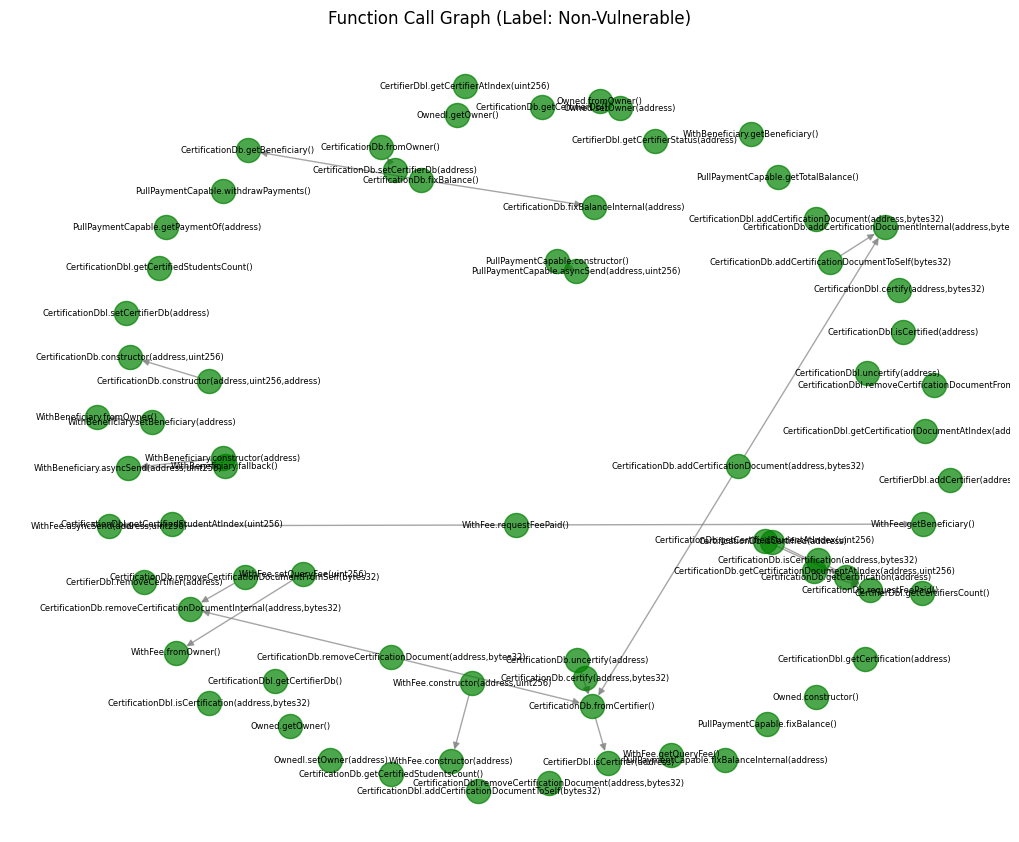

Graph visualization saved to graph_visualization.png


In [5]:
from pathlib import Path
import glob

# Timestamp
# /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x880928e59a4ef3e3bb22e596f17081fd19e494c1.fcg
# /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0xb091e57acf198b660396ef4b5d883a5a9c556609.fcg

# Reentrancy
# /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/Vulnerable_Fcg/0x58fcf11196abaeefdf23198ec4ec9c5237963e17.fcg
# /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/Vulnerable_Fcg/0xe439d6db9d81b04d6e0c0604b8121e85f3cfa66b.fcg

# data_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/Vulnerable_Fcg"
# sample_file = glob.glob(data_path + "/*.fcg")[55]  # Get the first .fcg file
# print(sample_file)

fcg_testF_file = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable_Fcg/0x1e5028fcb334d79633f5a6665347d2eaa02cb406.fcg"
path_label = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable_Fcg/0x1e5028fcb334d79633f5a6665347d2eaa02cb406_mapping.json"
sample_file = fcg_testF_file
print(sample_file)
sample_label = 0 if "NonVulnerable" in str(sample_file) else 1  # Infer label from directory

visualize_graph(str(sample_file), path_label, sample_label)

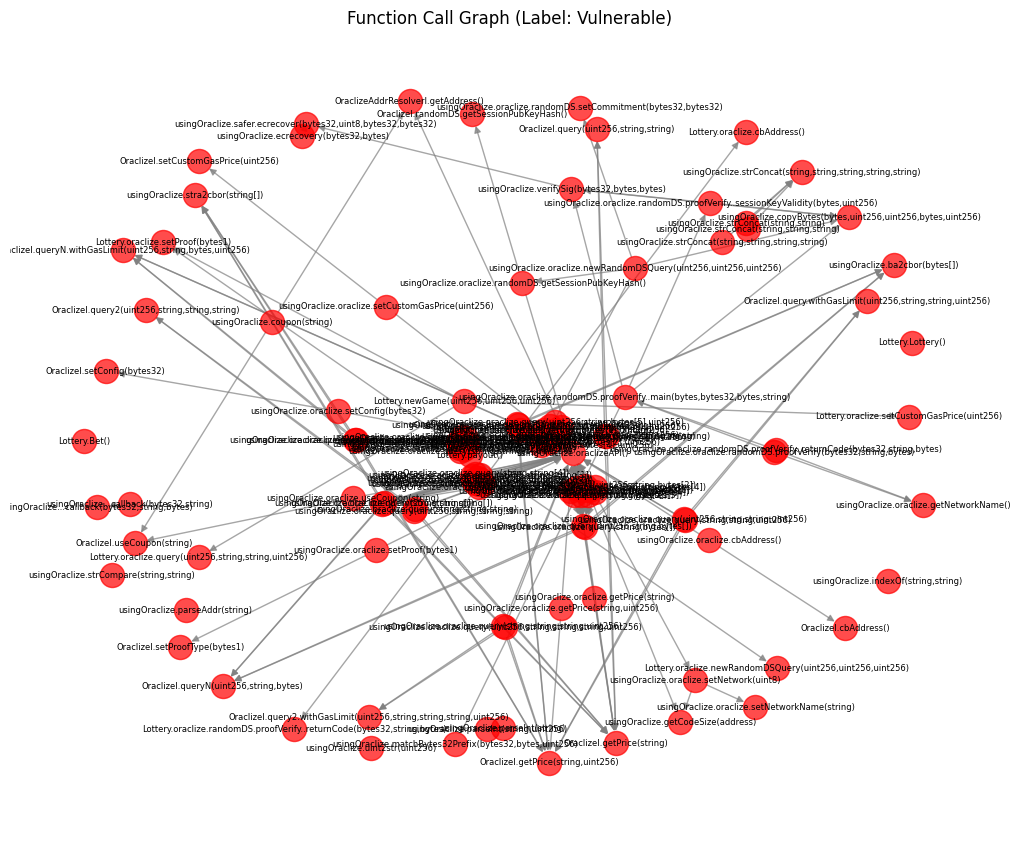

Graph visualization saved to graph_visualization.png


In [6]:
src_sol = "/kaggle/input/sc-vul-detection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable/0x880928e59a4ef3e3bb22e596f17081fd19e494c1.sol"
src_fcg = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x880928e59a4ef3e3bb22e596f17081fd19e494c1.fcg"
path_label = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x880928e59a4ef3e3bb22e596f17081fd19e494c1_mapping.json"
sample_file = src_fcg
sample_label = 0 if "NonVulnerable" in str(sample_file) else 1  # Infer label from directory

visualize_graph(str(sample_file), path_label, sample_label)

/usr/local/lib/python3.11/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


GraphNN(
  (conv1): GraphConv(in=768, out=2048, normalization=both, activation=<function relu at 0x7b3269d7b920>)
  (conv2): GraphConv(in=2048, out=2048, normalization=both, activation=<function relu at 0x7b3269d7b920>)
  (pooling): MaxPooling()
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


Epoch 0: 100%|██████████| 3/3 [00:00<00:00,  3.77it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 0, Loss: 1.1484, Train Accuracy: 52.67%
Val Accuracy: 26.15%, F1: 0.00%, Precision: 0.00%, Recall: 0.00%
Best model currently have 0.00% f1 in Evaluation


Epoch 1: 100%|██████████| 3/3 [00:00<00:00, 19.48it/s]


...

Epoch 97, Loss: 0.2111, Train Accuracy: 91.67%
Val Accuracy: 72.31%, F1: 80.43%, Precision: 84.09%, Recall: 77.08%


Epoch 98: 100%|██████████| 3/3 [00:00<00:00, 34.24it/s]


Epoch 98, Loss: 0.2070, Train Accuracy: 92.67%
Val Accuracy: 72.31%, F1: 80.43%, Precision: 84.09%, Recall: 77.08%


Epoch 99: 100%|██████████| 3/3 [00:00<00:00, 33.44it/s]


Epoch 99, Loss: 0.2135, Train Accuracy: 92.33%
Val Accuracy: 76.92%, F1: 85.98%, Precision: 77.97%, Recall: 95.83%


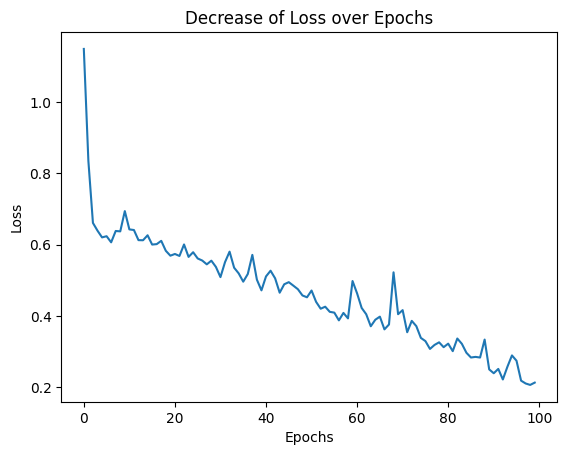

In [7]:
# Initialize GraphNN model
n_feats = 768
hfeats = [2048, 2048]
model = GraphNN(
    mtype=["GCN"],
    feat=n_feats,
    hfeats=hfeats,
    fc1_layer=256,
    fc2_layer=64,
    outclass=2,
    gptype="max",
    num_query_vectors=2
)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)
print(model)

optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

# Training loop
result = {
    "loss": [],
    "val_acc": [],
    "val_f1": [],
    "epoch": []
}

best_f1 = -1

model.train()
for epoch in range(100):
    bloss, bpred, blabel = [], [], []
    for batched_graph, labels in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
        batched_graph = batched_graph.to(device)
        labels = labels.to(device)
        feats = batched_graph.ndata['features']
        preds = model(batched_graph, feats)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        bloss.append(loss.item())
        bpred.extend(preds.argmax(dim=1).tolist())
        blabel.extend(labels.tolist())
    avg_loss = sum(bloss) / len(bloss)
    result['loss'].append(avg_loss)
    result['epoch'].append(epoch)
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, Train Accuracy: {(accuracy_score(bpred, blabel) * 100):.2f}%")

    # Evaluate
    model.eval()
    with torch.no_grad():
        tpred, tlabel = [], []
        for batched_graph, labels in test_dataloader:
            batched_graph = batched_graph.to(device)
            labels = labels.to(device)
            feats = batched_graph.ndata['features']
            preds = model(batched_graph, feats)
            tpred.extend(preds.argmax(dim=1).tolist())
            tlabel.extend(labels.tolist())
        val_acc = accuracy_score(tlabel, tpred) * 100
        val_f1 = f1_score(tlabel, tpred) * 100
        val_precision = precision_score(tlabel, tpred) * 100
        val_recall = recall_score(tlabel, tpred) * 100
        result['val_acc'].append(val_acc / 100)
        result['val_f1'].append(val_f1 / 100)
        print(f"Val Accuracy: {val_acc:.2f}%, F1: {val_f1:.2f}%, Precision: {val_precision:.2f}%, Recall: {val_recall:.2f}%")
        if val_f1 > best_f1:
            print(f"Best model currently have {val_f1:.2f}% f1 in Evaluation")
            model.save("/kaggle/working/best_model.pt")
            best_f1 = val_f1
    model.train()

# Plot loss
plt.plot(result["epoch"], result["loss"])
plt.title("Decrease of Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [8]:
print(best_f1) # 88.8888888888889

88.8888888888889


In [9]:
model.load("/kaggle/working/best_model.pt")

In [38]:
# Visualization function with fixed edge_colors
def visualize_explanation(graph, path_label, edge_weights, node_keep, top_k=10, title="Explanation Subgraph"):
    u, v = graph.edges()
    nx_graph = nx.Graph()
    nx_graph.add_edges_from(zip(u.tolist(), v.tolist()))
    
    edge_weights = edge_weights.cpu().detach().numpy()
    edge_weights = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-10)
    if top_k > len(edge_weights):
        top_k = len(edge_weights)
    indices = np.argsort(edge_weights)[-top_k:]
    important_edges = [(u.item(), v.item()) for i, (u, v) in enumerate(zip(u, v)) if i in indices]
    edge_colors = [edge_weights[i] for i in indices]  # Scalars for colormap
    
    sub_graph = nx.Graph()
    sub_graph.add_edges_from(important_edges)
    important_nodes = set([u for u, v in important_edges] + [v for u, v in important_edges])
    for node in important_nodes:
        sub_graph.add_node(node)
    
    with open(path_label, "r", encoding="utf-8") as file:
        mapping = json.load(file)
    mapping_node = mapping["node"]
    mapping_node = {idx: node.split("(")[0].split(".")[1] for idx, (node, data) in enumerate(mapping_node.items())}
    
    pos = nx.spring_layout(sub_graph, seed=42)
    plt.figure(figsize=(6, 6))
    nx.draw_networkx_nodes(sub_graph, pos, node_color='lightblue', node_size=100)
    nx.draw_networkx_edges(sub_graph, pos, edge_color='gray', alpha=0.3)
    nx.draw_networkx_edges(sub_graph, pos, edgelist=important_edges, edge_color=edge_colors, edge_cmap=plt.cm.Reds, width=2)
    nx.draw_networkx_labels(
        sub_graph, 
        pos, 
        labels={n: f"{n}: {mapping_node.get(n, 'Unknown')}" for n in sub_graph.nodes() if mapping_node.get(n, 'Unknown') == node_keep},
        font_size=16
    )
    plt.title(title)
    # Modified colorbar to increase font size of "Edge Importance" label
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0, vmax=1)), label='Edge Importance')
    cbar.set_label('Edge Importance', fontsize=16)  # Increased font size
    cbar.ax.tick_params(labelsize=16)  # Optional: Increase tick label size
    plt.show()
    print("Important nodes:", [f"{n}: {mapping_node.get(n, 'Unknown')}" for n in sub_graph.nodes()])
    return important_edges

Prediction: 1, True label: 1


Explain graph: 100%|██████████| 200/200 [00:01<00:00, 130.80it/s]
/tmp/ipykernel_31/3162294246.py:39: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0, vmax=1)), label='Edge Importance')


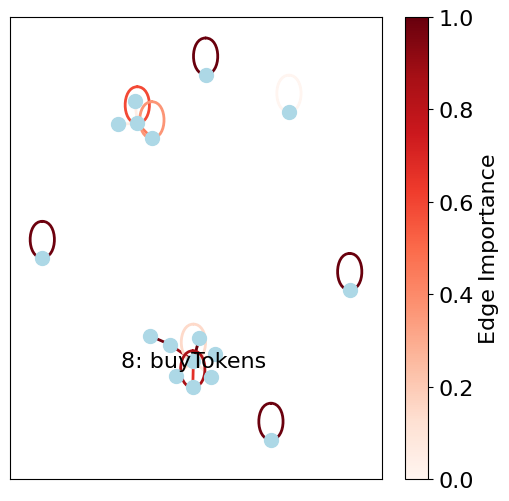

Important nodes: ['1: createTokenContract', '2: validPurchase', '8: buyTokens', '5: init', '11: ifIssuer', '6: finalise', '3: accruedBonus', '27: div', '28: add', '10: mop', '12: fallback', '16: allocate', '22: ifHolder', '17: allowance', '20: approve', '21: ERC20', '24: balanceOf']
Mapping node sample: [(0, 'LitmusCrowdsale.timeElapsed()'), (1, 'LitmusCrowdsale.createTokenContract()'), (2, 'LitmusCrowdsale.validPurchase()'), (3, 'LitmusCrowdsale.accruedBonus(uint256,uint256)'), (4, 'LitmusCrowdsale.verifyYourBalance(address)'), (5, 'LitmusCrowdsale.init()'), (6, 'LitmusCrowdsale.finalise()'), (7, 'LitmusCrowdsale.icoFunded()'), (8, 'LitmusCrowdsale.buyTokens()'), (9, 'LitmusCrowdsale.goalReached()')]
Vulnerable nodes in subgraph: 3/4
Vulnerable node names: ['LitmusCrowdsale.validPurchase()', 'LitmusCrowdsale.accruedBonus(uint256,uint256)', 'LitmusCrowdsale.mop()']
Feature mask shape: torch.Size([768])
Top 10 feature indices: [663, 516, 235, 634, 528, 108, 167, 273, 610, 606]
Top 10 fe

In [39]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Initialize GNNExplainer
explainer = GNNExplainer(
    model,
    num_hops=2, 
    lr=0.01,
    num_epochs=200,
    alpha1=0.005, 
    alpha2=1.0,   
    beta1=0.1,    
    beta2=0.1,    
    log=True
)

dir_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg"
# Explain a specific test graph
file_name = "0x18a4d3c8b51713355adc925e9a23ef278fd51f2f"
graph_path = f"{dir_path}/{file_name}.fcg"
path_label = f"{dir_path}/{file_name}_mapping.json"
graph, label = loadfeatureGraph_100(graph_path)
graph = dgl.to_simple(dgl.add_self_loop(dgl.to_bidirected(graph, copy_ndata=True)))
label = torch.tensor(1)
graph = graph.to(device)
graph_feat = graph.ndata['featuresH']

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(graph=graph, feat=graph_feat)
    pred = logits.argmax(dim=1).item()
print(f'Prediction: {pred}, True label: {label}')

# Run GNNExplainer
feat_mask, edge_mask = explainer.explain_graph(graph, graph_feat)

# Visualize explanation subgraph
important_edges = visualize_explanation(graph, path_label, edge_mask, top_k=20, title="", node_keep="buyTokens")

# Validate vulnerable functions
with open(path_label, "r", encoding="utf-8") as file:
    mapping = json.load(file)
mapping_node = mapping["node"]
mapping_node = {idx: node for node, idx in mapping_node.items()}
mapping_code = mapping["code"]

# Debug: Print mapping_node to inspect node names
print("Mapping node sample:", list(mapping_node.items())[:10])

# Handle non-string node names
vulnerable_nodes = []
for idx, node in mapping_node.items():
    try:
        if isinstance(node, str) and ("block.timestamp" in mapping_code[node] or "now" in mapping_code[node]):
            vulnerable_nodes.append(idx)
    except:
        pass
important_nodes = set([u for u, v in important_edges] + [v for u, v in important_edges])
vuln_in_subgraph = len(set(vulnerable_nodes) & important_nodes)
print(f"Vulnerable nodes in subgraph: {vuln_in_subgraph}/{len(vulnerable_nodes)}")
print(f"Vulnerable node names: {[mapping_node.get(n, 'Unknown') for n in vulnerable_nodes if n in important_nodes]}")

# Analyze feature mask
print(f"Feature mask shape: {feat_mask.shape}")
print(f"Top 10 feature indices: {torch.argsort(feat_mask, descending=True)[:10].tolist()}")
print(f"Top 10 feature importances: {feat_mask[torch.argsort(feat_mask, descending=True)[:10]].tolist()}")

Prediction: 1, True label: 1


Explain graph: 100%|██████████| 200/200 [00:01<00:00, 130.02it/s]
/tmp/ipykernel_31/3162294246.py:39: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0, vmax=1)), label='Edge Importance')


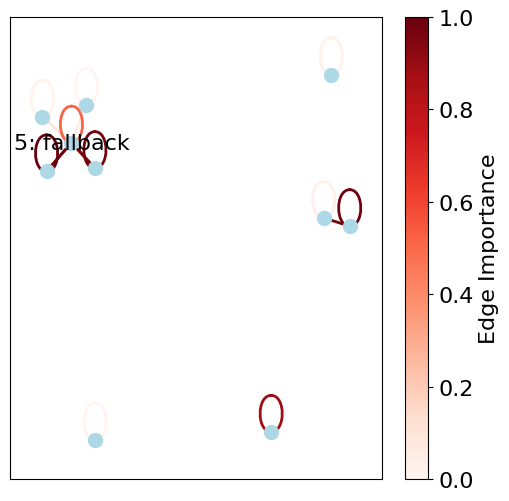

Important nodes: ['0: add', '5: fallback', '1: mul', '2: sub', '3: div', '4: onlyOwner', '8: withdrawStuck', '7: withinTimeLimit', '9: belowCap', '6: Mainsale']
Mapping node sample: [(0, 'SafeMath.add(uint256,uint256)'), (1, 'SafeMath.mul(uint256,uint256)'), (2, 'SafeMath.sub(uint256,uint256)'), (3, 'SafeMath.div(uint256,uint256)'), (4, 'Mainsale.onlyOwner()'), (5, 'Mainsale.fallback()'), (6, 'Mainsale.Mainsale(address,uint256)'), (7, 'Mainsale.withinTimeLimit()'), (8, 'Mainsale.withdrawStuck()'), (9, 'Mainsale.belowCap()')]
Vulnerable nodes in subgraph: 2/2
Vulnerable node names: ['Mainsale.Mainsale(address,uint256)', 'Mainsale.withinTimeLimit()']
Feature mask shape: torch.Size([768])
Top 10 feature indices: [550, 318, 278, 519, 437, 663, 195, 534, 367, 108]
Top 10 feature importances: [0.845020055770874, 0.8374728560447693, 0.8357378244400024, 0.8335826396942139, 0.8321302533149719, 0.8297160863876343, 0.8273619413375854, 0.8260589241981506, 0.8208755850791931, 0.8201025128364563]


In [40]:
# Initialize GNNExplainer
explainer = GNNExplainer(
    model,
    num_hops=2,  # Match GraphNN's two SAGEConv layers
    lr=0.01,
    num_epochs=200,
    alpha1=0.005,  # Encourage sparse edge mask (sum)
    alpha2=1.0,    # Encourage sparse edge mask (entropy)
    beta1=0.1,     # Encourage sparse feature mask (sum)
    beta2=0.1,     # Encourage sparse feature mask (entropy)
    log=True
)

dir_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg"
# Explain a specific test graph
file_name = "0xbdB94f1bCd37846F2F333604e8eB3ec247f0A461"
graph_path = f"{dir_path}/{file_name}.fcg"
path_label = f"{dir_path}/{file_name}_mapping.json"
graph, label = loadfeatureGraph_100(graph_path)
graph = dgl.to_simple(dgl.add_self_loop(dgl.to_bidirected(graph, copy_ndata=True)))
label = torch.tensor(1)
graph = graph.to(device)
graph_feat = graph.ndata['featuresH']

# Get model prediction
model.eval()
with torch.no_grad():
    logits = model(graph=graph, feat=graph_feat)
    pred = logits.argmax(dim=1).item()
print(f'Prediction: {pred}, True label: {label}')

# Run GNNExplainer
feat_mask, edge_mask = explainer.explain_graph(graph, graph_feat)

# Visualize explanation subgraph
important_edges = visualize_explanation(graph, path_label, edge_mask, top_k=20, title="", node_keep="fallback")

# Validate vulnerable functions
with open(path_label, "r", encoding="utf-8") as file:
    mapping = json.load(file)
mapping_node = mapping["node"]
mapping_node = {idx: node for node, idx in mapping_node.items()}
mapping_code = mapping["code"]

# Debug: Print mapping_node to inspect node names
print("Mapping node sample:", list(mapping_node.items())[:10])

# Handle non-string node names
vulnerable_nodes = []
for idx, node in mapping_node.items():
    try:
        if isinstance(node, str) and ("block.timestamp" in mapping_code[node] or "now" in mapping_code[node]):
            vulnerable_nodes.append(idx)
    except:
        pass
important_nodes = set([u for u, v in important_edges] + [v for u, v in important_edges])
vuln_in_subgraph = len(set(vulnerable_nodes) & important_nodes)
print(f"Vulnerable nodes in subgraph: {vuln_in_subgraph}/{len(vulnerable_nodes)}")
print(f"Vulnerable node names: {[mapping_node.get(n, 'Unknown') for n in vulnerable_nodes if n in important_nodes]}")

# Analyze feature mask
print(f"Feature mask shape: {feat_mask.shape}")
print(f"Top 10 feature indices: {torch.argsort(feat_mask, descending=True)[:10].tolist()}")
print(f"Top 10 feature importances: {feat_mask[torch.argsort(feat_mask, descending=True)[:10]].tolist()}")

In [24]:
import json
with open("/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x042a277368cb43A70b06361E7ab7D1D0A2096B0e_mapping.json", "r", encoding="utf-8") as file:
    mapping = json.load(file)
mapping_node = mapping["node"]
mapping_node = {idx:node for idx, (node, data) in enumerate(mapping_node.items())}
mapping_code = mapping["code"]

In [25]:
# Visualization function with fixed edge_colors
def vexplanation(graph, path_label, edge_weights, top_k=10, title="Explanation Subgraph"):
    u, v = graph.edges()
    nx_graph = nx.Graph()
    nx_graph.add_edges_from(zip(u.tolist(), v.tolist()))
    
    edge_weights = edge_weights.cpu().detach().numpy()
    edge_weights = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-10)
    if top_k > len(edge_weights):
        top_k = len(edge_weights)
    indices = np.argsort(edge_weights)[-top_k:]
    important_edges = [(u.item(), v.item()) for i, (u, v) in enumerate(zip(u, v)) if i in indices]
    return important_edges

# Directory with .fcg files
directory = "/kaggle/input/sc-vul-detection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Test/Vulnerable"
one_vul_paths = []

for path in os.listdir(directory):
    if path.endswith(".sol"):
        bt, n = 0, 0
        with open(f"{directory}/{path}", "r", encoding="utf-8") as f:
            lines = f.readlines()
        for line in lines:
            if "block.timestamp" in line:
                bt += 1
            elif "now" in line:
                n += 1
        if (bt == 1 and n == 0) or (bt == 0 and n == 1):
            tmp = f"{directory}/{path}".replace("sc-vul-detection-dataset", "sol2graphconverter").replace("Test/Vulnerable", "Test/Vulnerable_Fcg")[:-4]
            one_vul_paths.append(tmp)

print(len(one_vul_paths))

44


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Vexplanation function
def vexplanation(graph, path_label, edge_weights, node_embeddings, top_k=10, title="Explanation Subgraph"):
    u, v = graph.edges()
    nx_graph = nx.Graph()
    nx_graph.add_edges_from(zip(u.tolist(), v.tolist()))
    
    edge_weights = edge_weights.cpu().detach().numpy()
    edge_weights = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-10)
    if top_k > len(edge_weights):
        top_k = len(edge_weights)
    
    sorted_edges = sorted([(w, i) for i, w in enumerate(edge_weights)], key=lambda x: (-x[0], x[1]))
    indices = [i for _, i in sorted_edges[:top_k]]
    
    important_edges = [(u.item(), v.item()) for i, (u, v) in enumerate(zip(u, v)) if i in indices]
    important_nodes = set([u for u, v in important_edges] + [v for u, v in important_edges])
    
    with open(path_label, "r", encoding="utf-8") as file:
        mapping = json.load(file)
    mapping_node = mapping.get("node", {})
    mapping_node = {idx:node for idx, (node, data) in enumerate(mapping_node.items())}
    mapping_code = mapping.get("code", {})
    
    node_names = {idx: mapping_node.get(idx, str(idx)) for idx in important_nodes if idx in mapping_node}
    node_embeds = {idx: node_embeddings[idx].cpu().numpy() for idx in important_nodes if idx < len(node_embeddings)}
    
    # Identify vulnerable nodes
    vuln_nodes = [
        idx for idx in important_nodes
        if idx in mapping_node and isinstance(mapping_node[idx], str)
        and ("block.timestamp" in mapping_code.get(mapping_node[idx], "") or "now" in mapping_code.get(mapping_node[idx], ""))
    ]
    
    return important_edges, important_nodes, node_names, node_embeds, vuln_nodes

# Compute node similarity (structural)
def compute_node_similarity(nodes1, nodes2):
    nodes1_set = set(n for n in nodes1.values() if isinstance(n, str))
    nodes2_set = set(n for n in nodes2.values() if isinstance(n, str))
    if not nodes1_set or not nodes2_set:
        return 0.0
    intersection = len(nodes1_set & nodes2_set)
    union = len(nodes1_set | nodes2_set)
    return intersection / union if union > 0 else 0.0

# Main function
def evaluate_graph_similarity(directory, target_file, model, device, top_k=10):
    set_seed(42)
    
    # Validate inputs
    target_path = os.path.join(directory, target_file)
    target_label = target_path.replace(".fcg", "_mapping.json")
    if not os.path.exists(target_path) or not os.path.exists(target_label):
        print(f"Target file {target_path} or its mapping {target_label} not found")
        return
    
    # Step 1: Load all vulnerable graphs
    graphs_data = []
    target_graph_data = None
    for fcg_file in os.listdir(directory):
        if not fcg_file.endswith(".fcg"):
            continue
        graph_path = os.path.join(directory, fcg_file)
        path_label = graph_path.replace(".fcg", "_mapping.json")
        try:
            graph, label = loadfeatureGraph_100(graph_path)
            graph = dgl.to_simple(dgl.add_self_loop(dgl.to_bidirected(graph, copy_ndata=True)))
            with open(path_label, "r", encoding="utf-8") as file:
                mapping = json.load(file)
            mapping_node = mapping.get("node", {})
            mapping_node = {idx: node for node, idx in mapping_node.items()}
            mapping_code = mapping.get("code", {})
            
            graph_data = {
                "graph_path": graph_path,
                "path_label": path_label,
                "graph": graph,
                "graph_feat": graph.ndata['featuresH'],
                "mapping_node": mapping_node,
                "mapping_code": mapping_code
            }
            
            if graph_path == target_path:
                target_graph_data = graph_data
            else:
                graphs_data.append(graph_data)
        except Exception as e:
            print(f"Error processing {graph_path}: {e}")
    
    if target_graph_data is None:
        print(f"Target graph {target_path} failed to load")
        return
    
    print(f"Total vulnerable graphs: {len(graphs_data) + 1}")
    print(f"Target graph: {target_graph_data['graph_path']}")
    
    if not graphs_data:
        print("No other valid graphs to compare")
        return
    
    # Step 2: Extract graph embedding for target graph
    model.eval()
    target_graph = target_graph_data["graph"].to(device)
    target_feat = target_graph_data["graph_feat"].to(device)
    with torch.no_grad():
        target_graph_embedding = model(graph=target_graph, feat=target_feat, graph_embed=True)
        target_pred = model(graph=target_graph, feat=target_feat).argmax(dim=1).item()
    print(f"Prediction for target graph: {target_pred}, True label: 1")
    
    # Step 3: Find most similar graph based on graph embeddings
    max_similarity = -1
    most_similar_graph = None
    for graph_data in tqdm(graphs_data, desc="Comparing graph embeddings"):
        graph = graph_data["graph"].to(device)
        graph_feat = graph_data["graph_feat"].to(device)
        with torch.no_grad():
            graph_embedding = model(graph=graph, feat=graph_feat, graph_embed=True)
        similarity = cosine_similarity(
            target_graph_embedding.cpu().numpy().reshape(1, -1),
            graph_embedding.cpu().numpy().reshape(1, -1)
        )[0, 0]
        if similarity > max_similarity:
            max_similarity = similarity
            most_similar_graph = graph_data
    
    if most_similar_graph is None:
        print("No similar graphs found")
        return
    
    print(f"Most similar graph: {most_similar_graph['graph_path']}")
    print(f"Graph embedding similarity: {max_similarity:.4f}")
    
    # Step 4: Run GNNExplainer on both graphs
    explainer = GNNExplainer(
        model,
        num_hops=2,
        lr=0.01,
        num_epochs=500,
        alpha1=0.01,
        alpha2=2.0,
        beta1=0.1,
        beta2=0.1,
        log=True
    )
    
    graphs_to_explain = [target_graph_data, most_similar_graph]
    subgraphs = []
    
    for graph_data in graphs_to_explain:
        graph = graph_data["graph"].to(device)
        graph_feat = graph_data["graph_feat"].to(device)
        path_label = graph_data["path_label"]
        
        with torch.no_grad():
            node_embeddings = model(graph=graph, feat=graph_feat, embed=True)
            pred = model(graph=graph, feat=graph_feat).argmax(dim=1).item()
        print(f"Prediction for {graph_data['graph_path']}: {pred}, True label: 1")
        
        feat_mask, edge_mask = explainer.explain_graph(graph, graph_feat)
        important_edges, important_nodes, node_names, node_embeds, vuln_nodes = vexplanation(
            graph, path_label, edge_mask, node_embeddings, top_k=top_k, title=f"Subgraph for {os.path.basename(graph_data['graph_path'])}"
        )
        print(node_names)
        subgraphs.append({
            "edges": important_edges,
            "nodes": important_nodes,
            "node_names": node_names,
            "codes": graph_data["mapping_code"],
            "node_embeds": node_embeds,
            "vuln_nodes": vuln_nodes,
            "graph_path": graph_data["graph_path"]
        })
    
    # Step 5: Compute pairwise node similarities and find top 5 pairs
    subgraph1, subgraph2 = subgraphs
    
    # Get node embeddings and names
    nodes1 = list(subgraph1["node_names"].keys())
    nodes2 = list(subgraph2["node_names"].keys())
    if not nodes1 or not nodes2:
        print("No nodes in one or both subgraphs to compare")
        return
    
    # Compute cosine similarity for all pairs
    embeds1 = np.array([subgraph1["node_embeds"][idx] for idx in nodes1])
    embeds2 = np.array([subgraph2["node_embeds"][idx] for idx in nodes2])
    sim_matrix = cosine_similarity(embeds1, embeds2)
    
    # Collect all pairs with their similarities
    pairs = []
    for i, idx1 in enumerate(nodes1):
        for j, idx2 in enumerate(nodes2):
            similarity = sim_matrix[i, j]
            name1 = subgraph1["node_names"][idx1]
            name2 = subgraph2["node_names"][idx2]
            # print(subgraph1["codes"])
            try:
                code1 = subgraph1["codes"][name1]
            except:
                code1 = ""
            try:
                code2 = subgraph2["codes"][name2]
            except:
                code2 = ""
            is_vuln1 = idx1 in subgraph1["vuln_nodes"]
            is_vuln2 = idx2 in subgraph2["vuln_nodes"]
            pairs.append({
                "node1_idx": idx1,
                "node1_name": name1,
                "node2_idx": idx2,
                "node2_name": name2,
                "code1": code1,
                "code2": code2,
                "similarity": similarity,
                "vuln1": is_vuln1,
                "vuln2": is_vuln2
            })
    
    # Sort by similarity and get top 5
    top_pairs = sorted(pairs, key=lambda x: x["similarity"], reverse=True)[:5]
    
    # Structural similarity for context
    node_similarity = compute_node_similarity(subgraph1["node_names"], subgraph2["node_names"])
    edges1 = set(tuple(sorted(e)) for e in subgraph1["edges"])
    edges2 = set(tuple(sorted(e)) for e in subgraph2["edges"])
    edge_similarity = len(edges1 & edges2) / len(edges1 | edges2) if edges1 | edges2 else 0.0
    
    nodes1_set = set(subgraph1["node_names"].values())
    nodes2_set = set(subgraph2["node_names"].values())
    common_nodes = nodes1_set & nodes2_set
    non_vuln_nodes1 = {n for n in nodes1_set if "block.timestamp" not in n and "now" not in n}
    non_vuln_nodes2 = {n for n in nodes2_set if "block.timestamp" not in n and "now" not in n}
    common_non_vuln_nodes = non_vuln_nodes1 & non_vuln_nodes2
    
    vuln_in_subgraph1 = bool(set(subgraph1["vuln_nodes"]) & subgraph1["nodes"])
    vuln_in_subgraph2 = bool(set(subgraph2["vuln_nodes"]) & subgraph2["nodes"])
    
    # Step 6: Summarize results
    print("\nSubgraph Comparison:")
    print(f"Subgraph 1 nodes: {nodes1_set}")
    print(f"Subgraph 2 nodes: {nodes2_set}")
    print(f"Common nodes: {common_nodes}")
    print(f"Common non-vulnerable nodes: {common_non_vuln_nodes}")
    print(f"Node similarity (structural): {node_similarity:.4f}")
    print(f"Edge similarity (structural): {edge_similarity:.4f}")
    print(f"Vulnerable node in subgraph 1: {vuln_in_subgraph1}")
    print(f"Vulnerable node in subgraph 2: {vuln_in_subgraph2}")
    print("\nTop 5 Most Similar Node Pairs:")
    for i, pair in enumerate(top_pairs, 1):
        print(f"Pair {i}:")
        print(f"  Node 1: {pair['node1_name']} (idx: {pair['node1_idx']}, vulnerable: {pair['vuln1']})")
        print(f"  Node 2: {pair['node2_name']} (idx: {pair['node2_idx']}, vulnerable: {pair['vuln2']})")
        print(f"  Code 1:\n {pair['code1']}")
        print(f"  Code 2:\n {pair['code2']}")
        print(f"  Cosine Similarity: {pair['similarity']:.4f}")


directory = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg"
target_file = "0x18a4d3c8b51713355adc925e9a23ef278fd51f2f.fcg"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# Load pretrained model if available
# model.load("graphnn_model.pth")

evaluate_graph_similarity(directory, target_file, model, device, top_k=20)

Total vulnerable graphs: 384
Target graph: /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x18a4d3c8b51713355adc925e9a23ef278fd51f2f.fcg
Prediction for target graph: 1, True label: 1


Comparing graph embeddings: 100%|██████████| 383/383 [00:01<00:00, 244.33it/s]


Most similar graph: /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0xbdB94f1bCd37846F2F333604e8eB3ec247f0A461.fcg
Graph embedding similarity: 0.9975
Prediction for /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0x18a4d3c8b51713355adc925e9a23ef278fd51f2f.fcg: 1, True label: 1


Explain graph: 100%|██████████| 500/500 [00:03<00:00, 130.36it/s]


{6: 'LitmusCrowdsale.finalise()', 8: 'LitmusCrowdsale.buyTokens()', 10: 'LitmusCrowdsale.mop()', 11: 'LitmusCrowdsale.ifIssuer()', 12: 'LitmusCrowdsale.fallback()', 15: 'ERC20.transfer(address,uint256)', 16: 'ERC20.allocate(address,uint256)', 17: 'ERC20.allowance(address,address)', 18: 'ERC20.decreaseApproval(address,uint256)', 19: 'ERC20.transferFrom(address,address,uint256)', 20: 'ERC20.approve(address,uint256)', 21: 'ERC20.ERC20()', 22: 'ERC20.ifHolder()', 25: 'SafeMath.mul(uint256,uint256)', 26: 'SafeMath.sub(uint256,uint256)', 28: 'SafeMath.add(uint256,uint256)'}
Prediction for /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable_Fcg/0xbdB94f1bCd37846F2F333604e8eB3ec247f0A461.fcg: 1, True label: 1


Explain graph: 100%|██████████| 500/500 [00:03<00:00, 130.48it/s]

{0: 'SafeMath.add(uint256,uint256)', 1: 'SafeMath.mul(uint256,uint256)', 2: 'SafeMath.sub(uint256,uint256)', 3: 'SafeMath.div(uint256,uint256)', 4: 'Mainsale.onlyOwner()', 5: 'Mainsale.fallback()', 6: 'Mainsale.Mainsale(address,uint256)', 7: 'Mainsale.withinTimeLimit()', 8: 'Mainsale.withdrawStuck()', 9: 'Mainsale.belowCap()'}

Subgraph Comparison:
Subgraph 1 nodes: {'ERC20.transferFrom(address,address,uint256)', 'SafeMath.mul(uint256,uint256)', 'ERC20.allowance(address,address)', 'LitmusCrowdsale.fallback()', 'ERC20.ifHolder()', 'ERC20.allocate(address,uint256)', 'LitmusCrowdsale.ifIssuer()', 'LitmusCrowdsale.finalise()', 'SafeMath.add(uint256,uint256)', 'LitmusCrowdsale.buyTokens()', 'ERC20.transfer(address,uint256)', 'ERC20.decreaseApproval(address,uint256)', 'ERC20.ERC20()', 'LitmusCrowdsale.mop()', 'ERC20.approve(address,uint256)', 'SafeMath.sub(uint256,uint256)'}
Subgraph 2 nodes: {'Mainsale.onlyOwner()', 'SafeMath.mul(uint256,uint256)', 'Mainsale.withinTimeLimit()', 'Mainsale.be